# K‑Means Clustering: From Scratch to Real‑World Customer Segmentation

**Author:** Phabel Antonio López Delgado, BSc.

This notebook provides a comprehensive introduction to K‑Means clustering, one of the most widely used unsupervised learning algorithms. It covers:

- **Theoretical Foundations** – understanding the K‑Means algorithm, Euclidean distance, centroids, and inertia.
- **From‑Scratch Implementation** – implementing K‑Means and K‑Means++ from scratch using NumPy.
- **Comparison of Initialisation Methods** – visualising the convergence of K‑Means vs K‑Means++.
- **Optimal Number of Clusters** – using the Elbow Method and Silhouette Score.
- **Alternative Algorithms** – applying K‑Medoids (K‑Medians) using `scikit‑learn‑extra`.
- **Real‑World Case Study** – customer segmentation on a Netflix user dataset.

**Key Techniques & Libraries:**
- `numpy`, `pandas` – numerical computation and data manipulation
- `matplotlib`, `seaborn` – static visualisation
- `sklearn.cluster.KMeans` – efficient K‑Means implementation
- `sklearn_extra.cluster.KMedoids` – K‑Medoids (robust to outliers)
- `sklearn.datasets.make_blobs` – synthetic data generation
- `sklearn.metrics.silhouette_score` – cluster quality evaluation

**Data Sources:**
1. **Synthetic Data** – generated using `make_blobs` and random normal distributions.
2. **Netflix User Dataset** – loaded from `Netflix Userbase.csv` (publicly available for customer segmentation).

In [1]:
# %% Imports and Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# High-DPI for static plots
%config InlineBackend.figure_format = 'retina'

# Visualisation settings
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots directory exists
Path("plots").mkdir(exist_ok=True)

print("All imports successful.")

All imports successful.


## 1. Theoretical Background

K‑Means is a centroid‑based clustering algorithm that partitions data into `K` clusters by minimising the within‑cluster sum of squares (inertia). The algorithm iterates between two steps:

1. **Assignment Step:** Assign each point to the nearest centroid.
2. **Update Step:** Recalculate centroids as the mean of points in each cluster.

**Key Concepts:**
- **Centroid:** The mean position of all points in a cluster.
- **Inertia:** Sum of squared distances from each point to its cluster centroid.
- **K‑Means++:** An intelligent initialisation method that spreads centroids to improve convergence and avoid poor local minima.
- **Elbow Method:** Plot inertia vs. K to find the "elbow" where inertia decreases more slowly.
- **Silhouette Score:** Measures how similar a point is to its own cluster compared to other clusters (range: -1 to 1, higher is better).
"""

## 2. Synthetic Data Generation

We generate synthetic data using `make_blobs` to create well‑separated clusters for initial experimentation.

Generated 1000 samples with 8 true clusters.
Data shape: (1000, 2)


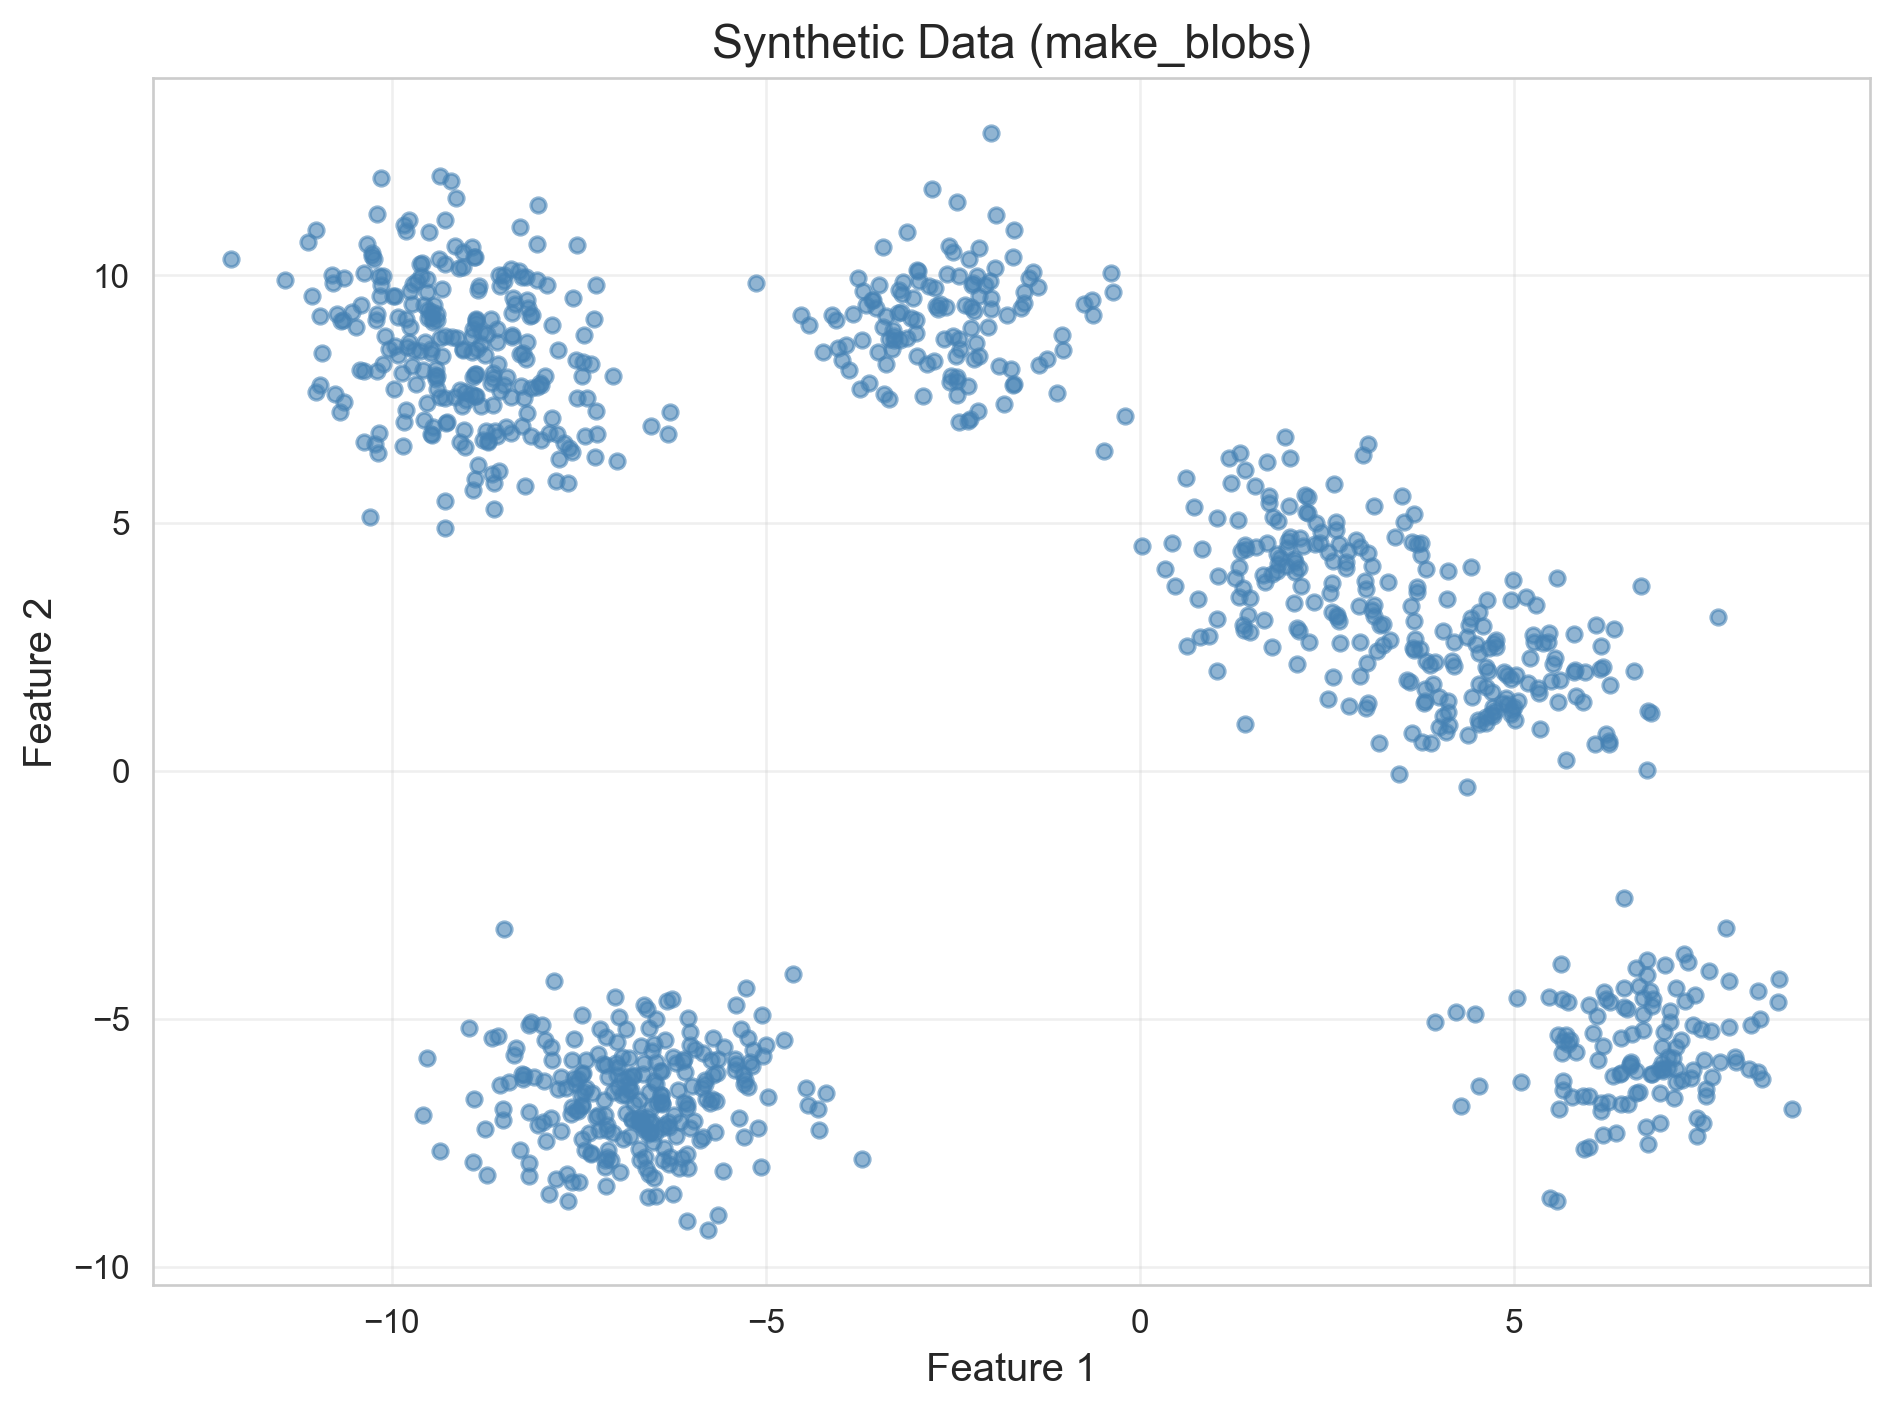

In [2]:
# %% Generate Synthetic Data
n_samples = 1000
n_features = 2
n_clusters = 8
random_state = 42
cluster_std = 1.0

X, y_true = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=n_clusters,
    random_state=random_state,
    cluster_std=cluster_std
)

print(f"Generated {n_samples} samples with {n_clusters} true clusters.")
print(f"Data shape: {X.shape}")

# Visualise
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.6, color='steelblue')
plt.title('Synthetic Data (make_blobs)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/synthetic_data.png', dpi=300)
plt.show()

## 3. K‑Means from Scratch

We implement K‑Means and K‑Means++ from scratch using NumPy to understand the inner workings of the algorithm.

In [3]:
# %% Helper Functions for K-Means
def euclidean_distance(a, b):
    """Compute Euclidean distance between two vectors."""
    return np.sqrt(np.sum((a - b) ** 2))

def plot_kmeans(X, centroids, labels, iteration, K, title_prefix='K-means'):
    """Plot clustering results at a given iteration."""
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']
    for k in range(K):
        cluster_points = X[labels == k]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                    c=colors[k % len(colors)], alpha=0.6, label=f'Cluster {k+1}')
    plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X', label='Centroids')
    plt.title(f'{title_prefix} Clustering - Iteration {iteration}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'plots/{title_prefix.lower()}_iter_{iteration}.png', dpi=300)
    plt.show()

In [4]:
# %% K-Means from Scratch
def kmeans_plus_plus_init(X, K, rs=42):
    """Initialise centroids using K-means++ algorithm."""
    np.random.seed(rs)
    n_samples = X.shape[0]
    centroids = np.zeros((K, X.shape[1]))
    centroids[0] = X[np.random.randint(n_samples)]
    
    for k in range(1, K):
        distances = np.array([min([euclidean_distance(x, c) for c in centroids[:k]]) for x in X])
        probabilities = distances / distances.sum()
        centroid_index = np.random.choice(n_samples, p=probabilities)
        centroids[k] = X[centroid_index]
    return centroids

def kmeans_algorithm(X, K, max_iters=100, init='random', rs=42):
    """
    Run K-Means algorithm with specified initialisation.
    Returns labels, centroids, and history of centroids.
    """
    np.random.seed(rs)
    n_samples, n_features = X.shape
    
    # Initialise centroids
    if init == 'random':
        centroids = X[np.random.choice(n_samples, K, replace=False)]
    elif init == 'kmeans++':
        centroids = kmeans_plus_plus_init(X, K, rs)
    else:
        raise ValueError("init must be 'random' or 'kmeans++'")
    
    labels = np.zeros(n_samples)
    history = [centroids.copy()]
    
    for iteration in range(max_iters):
        # Assignment step
        for i, point in enumerate(X):
            distances = [euclidean_distance(point, c) for c in centroids]
            labels[i] = np.argmin(distances)
        
        # Update step
        new_centroids = np.zeros((K, n_features))
        for k in range(K):
            points_in_cluster = X[labels == k]
            if len(points_in_cluster) > 0:
                new_centroids[k] = np.mean(points_in_cluster, axis=0)
            else:
                new_centroids[k] = centroids[k]  # keep old centroid if cluster is empty
        
        # Check convergence
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
        history.append(centroids.copy())
    
    return labels, centroids, history

### 3.1 Visualising K‑Means Convergence

We run K‑Means with both random and K‑Means++ initialisation and visualise the convergence process.

Visualising convergence of Random K-Means vs K-Means++...


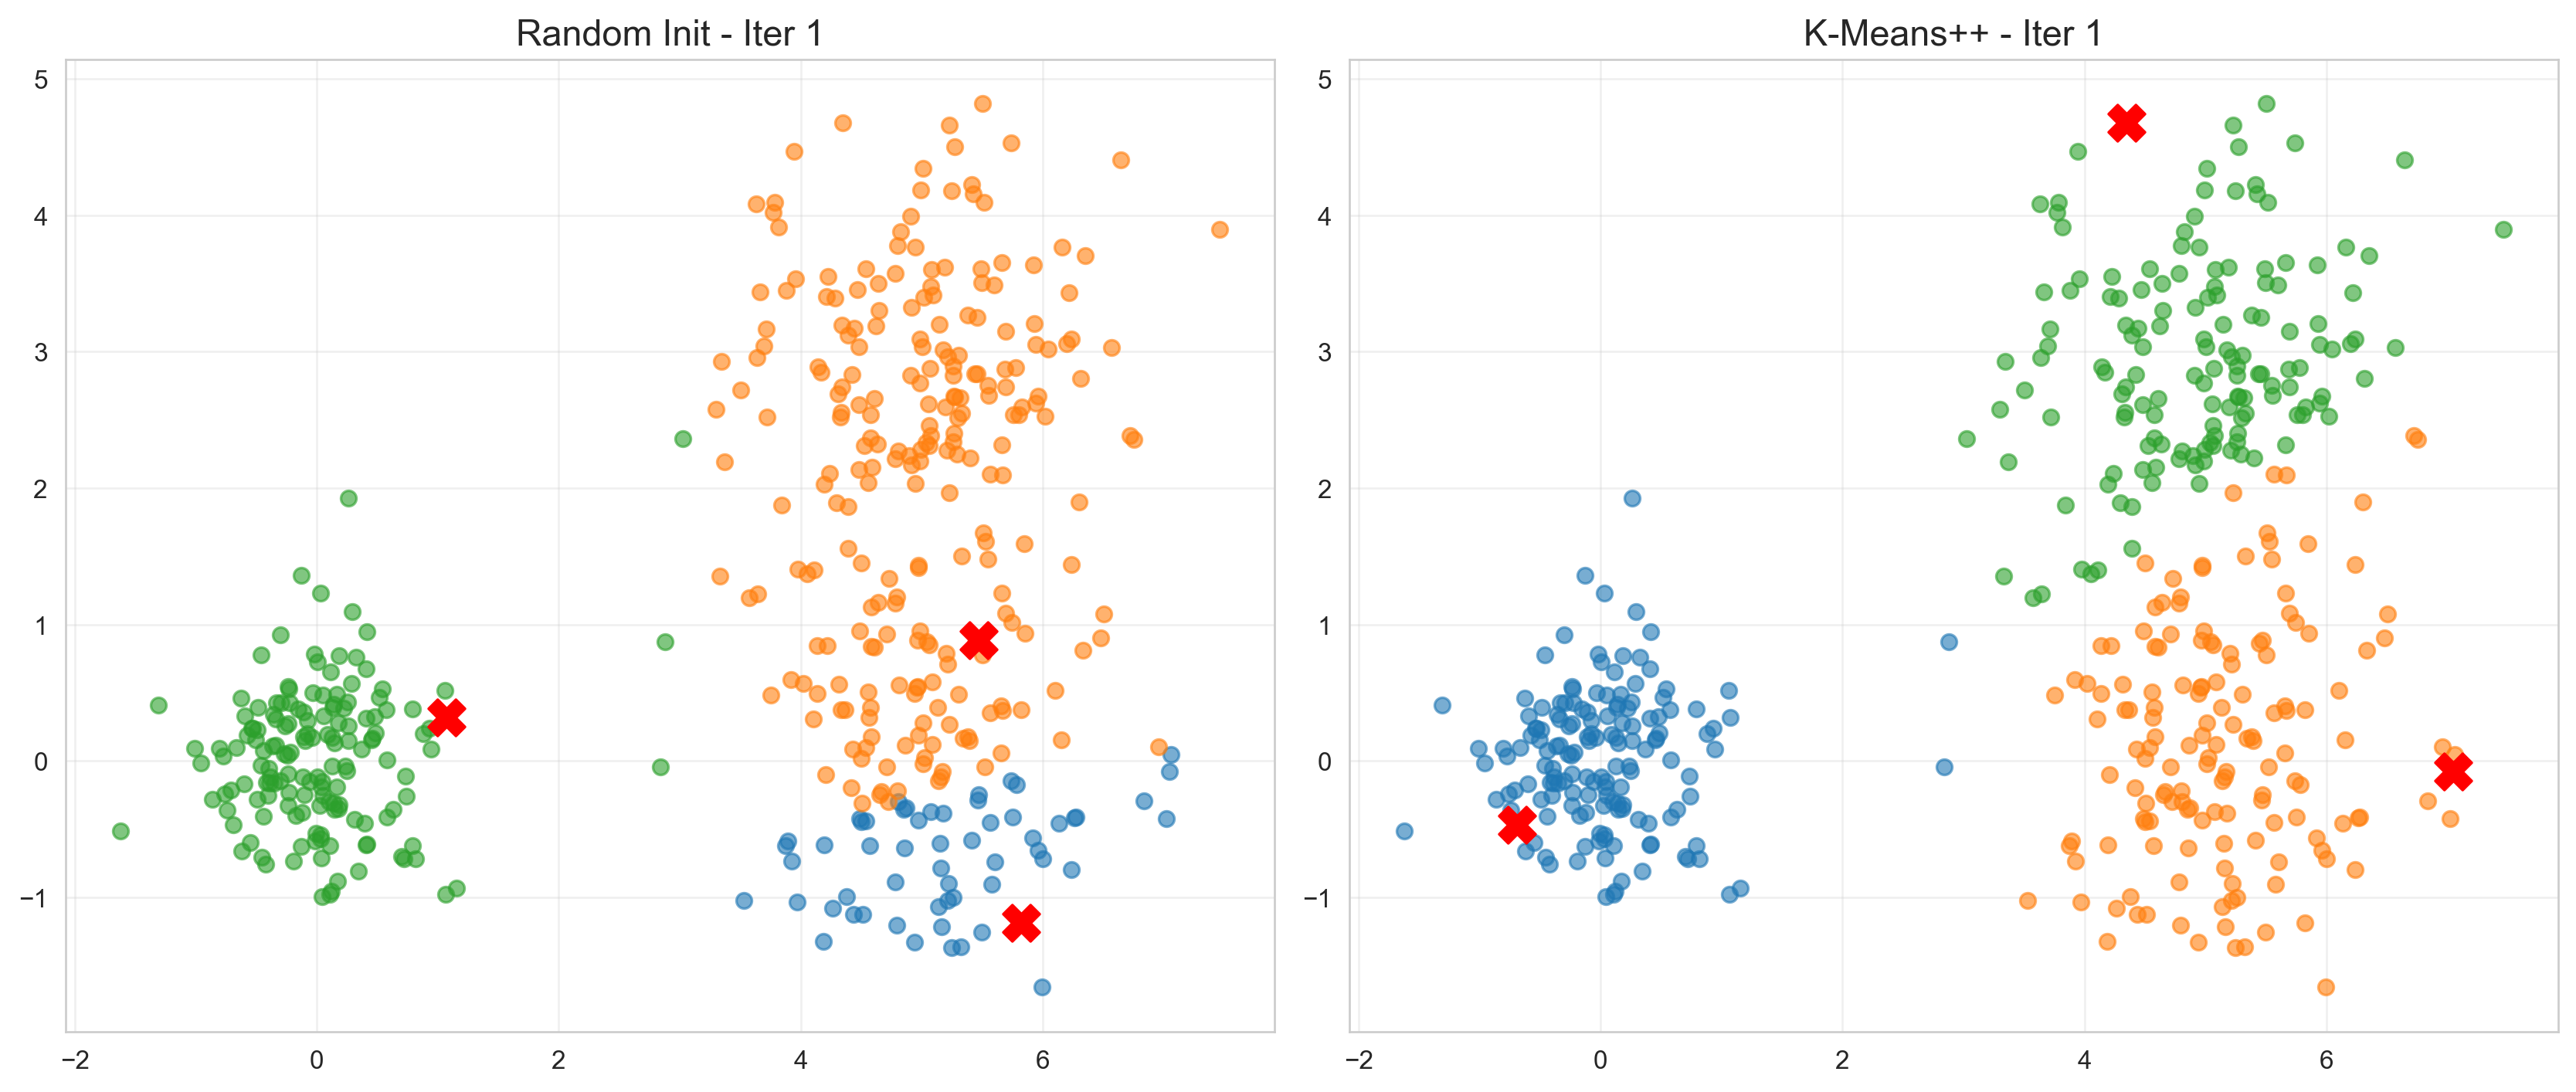

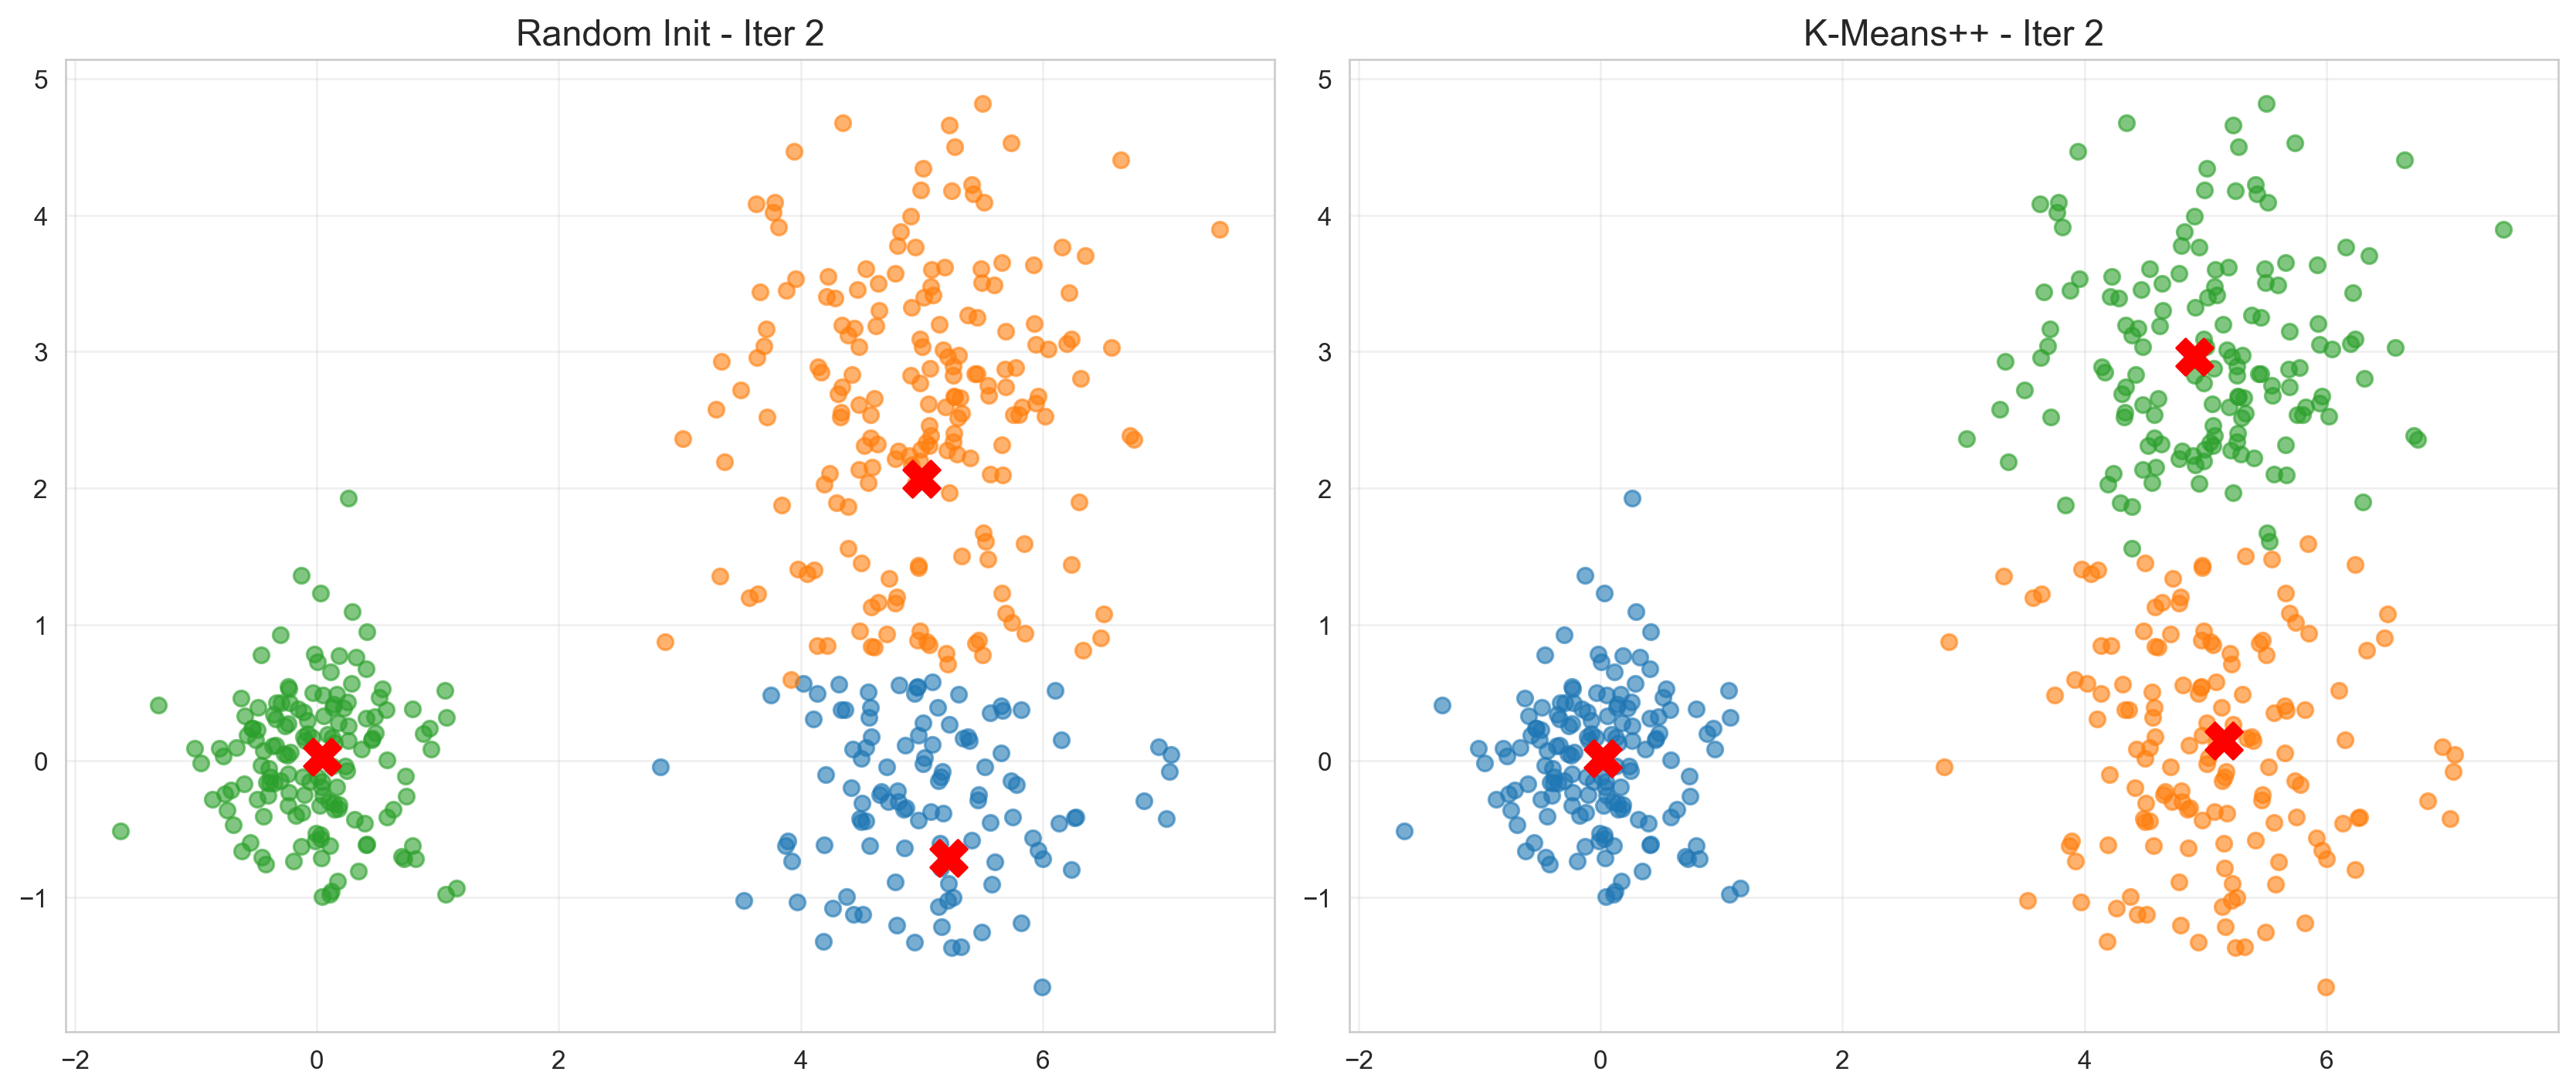

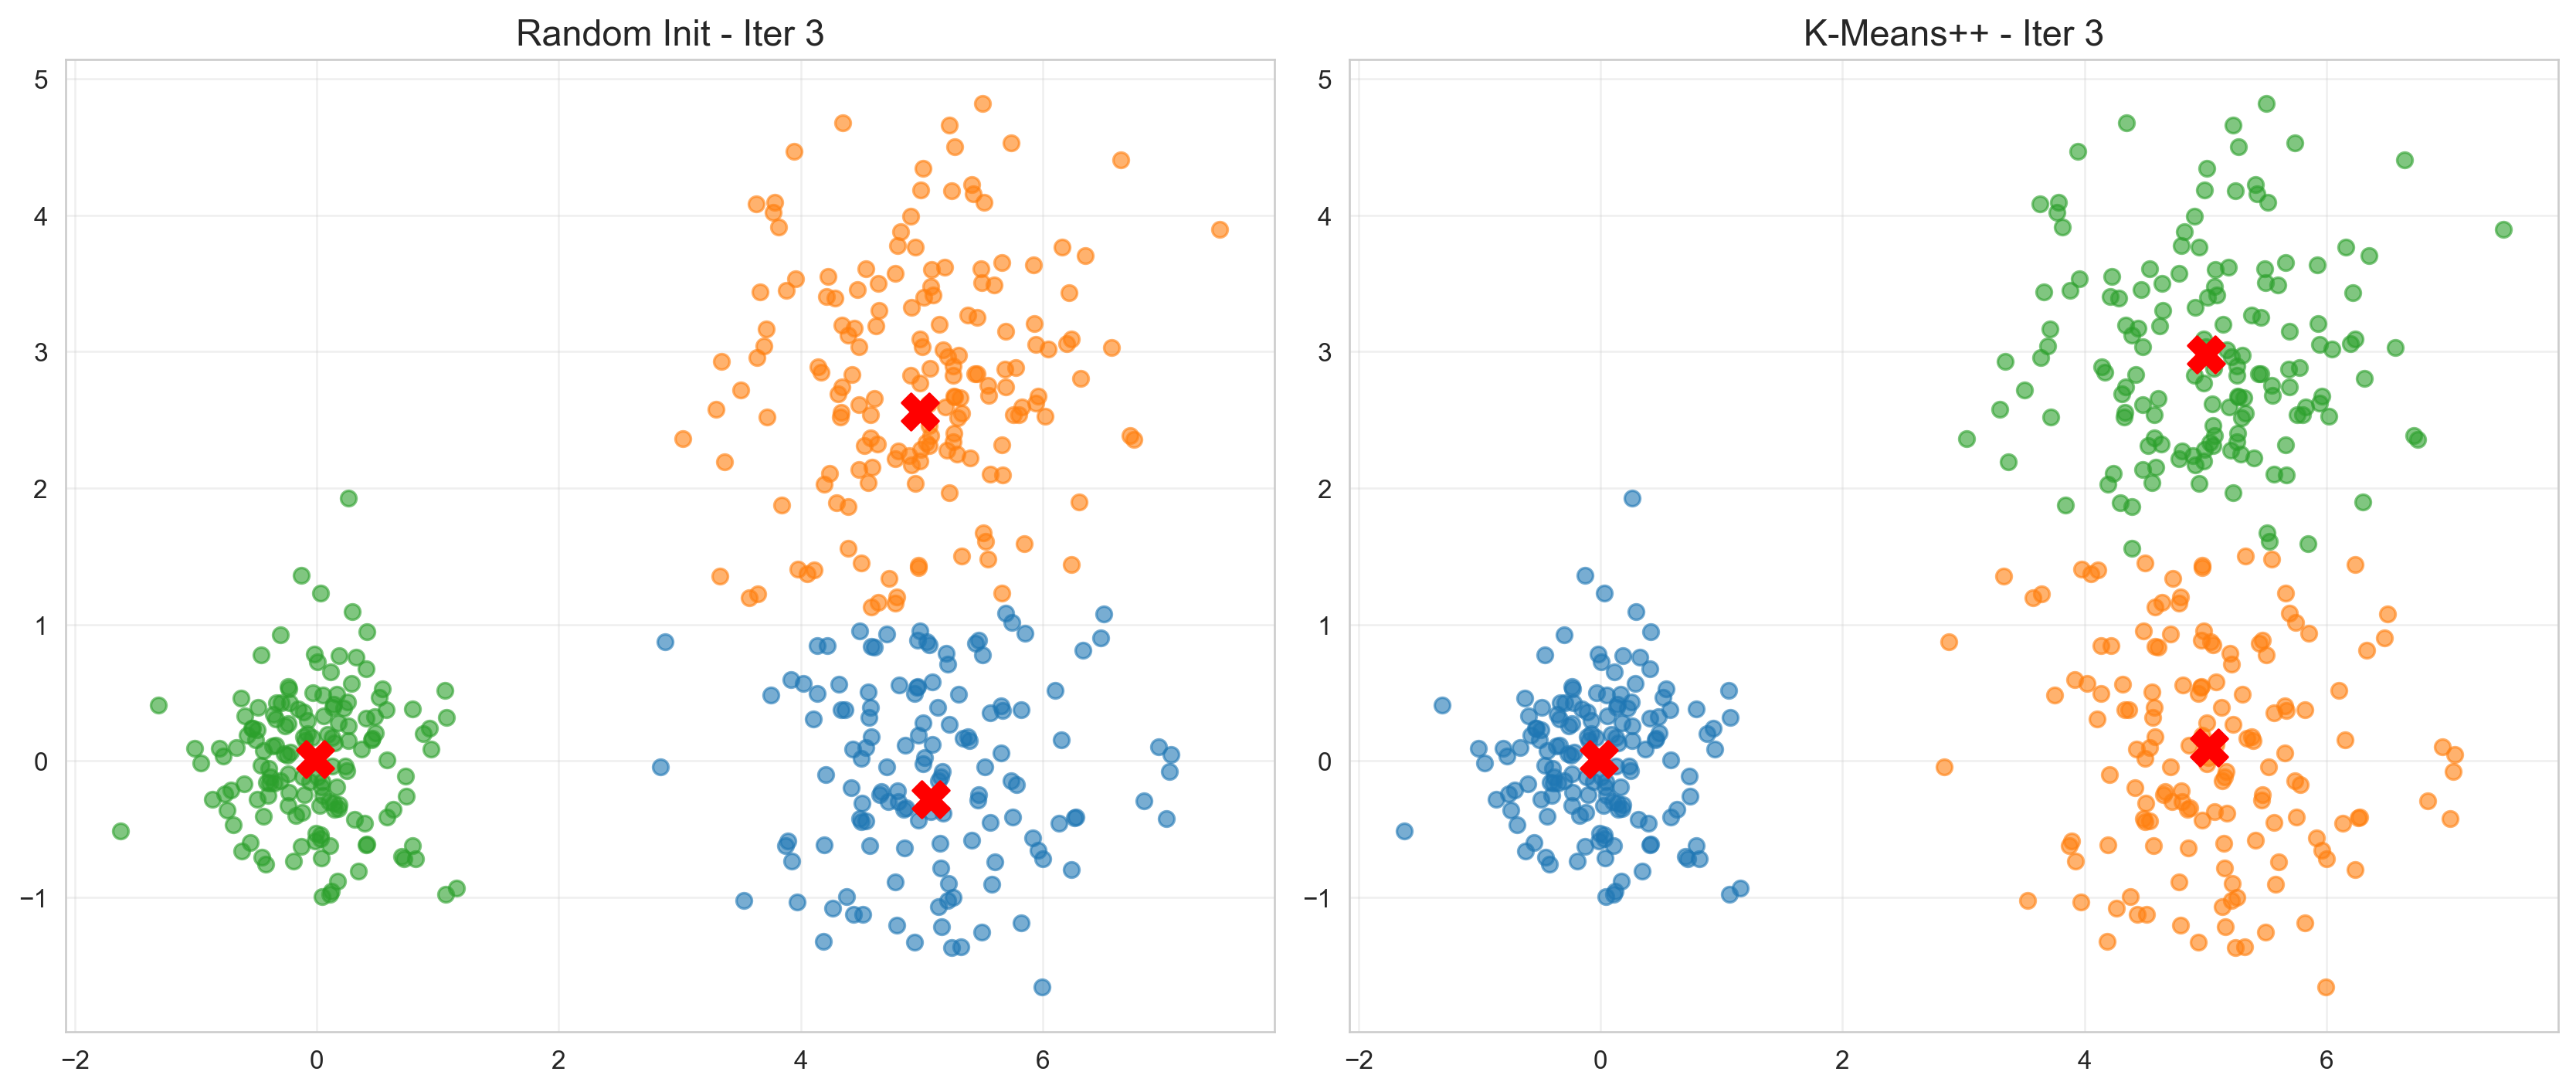

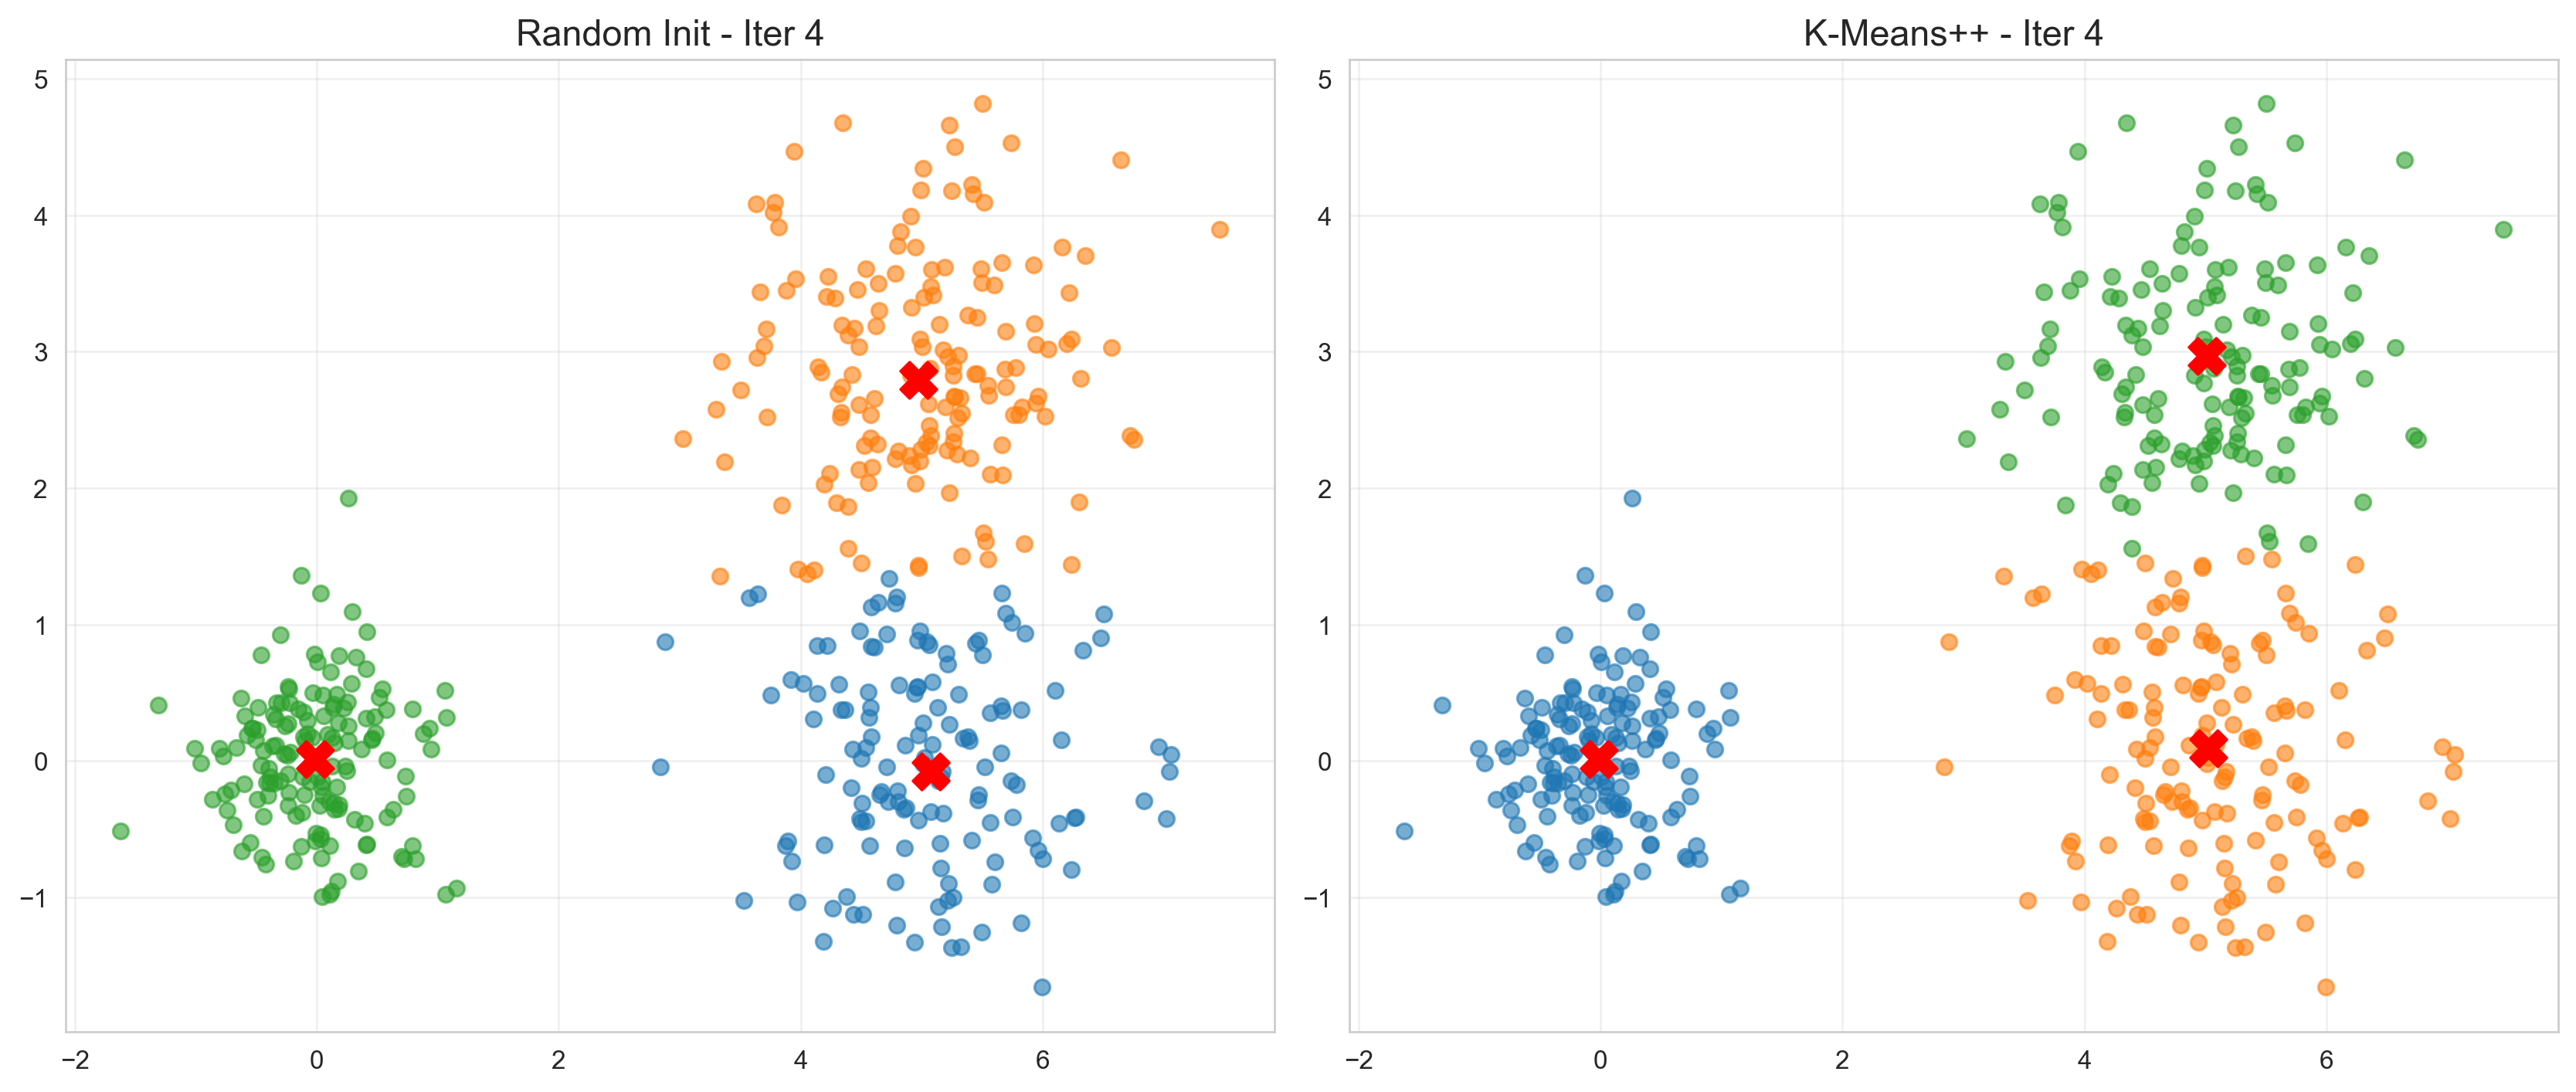


K-Means++ converges faster and to a better solution.


In [5]:
# %% Compare Random vs K-Means++
# Generate data for visualisation (simpler, 3 clusters)
np.random.seed(42)
X_vis = np.vstack([
    np.random.normal(loc=[0, 0], scale=0.5, size=(150, 2)),
    np.random.normal(loc=[5, 3], scale=0.8, size=(150, 2)),
    np.random.normal(loc=[5, 0], scale=0.8, size=(150, 2))
])

K_vis = 3
max_iters_vis = 10

# Run K-Means with random init
labels_random, centroids_random, history_random = kmeans_algorithm(
    X_vis, K_vis, max_iters=max_iters_vis, init='random', rs=42
)

# Run K-Means with K-means++ init
labels_pp, centroids_pp, history_pp = kmeans_algorithm(
    X_vis, K_vis, max_iters=max_iters_vis, init='kmeans++', rs=42
)

# Plot iterations side-by-side
print("Visualising convergence of Random K-Means vs K-Means++...")
for i in range(min(len(history_random), len(history_pp), 5)):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Random init
    labels_r = None
    for idx, point in enumerate(X_vis):
        distances_r = [euclidean_distance(point, c) for c in history_random[i]]
        if idx == 0:
            labels_r = np.zeros(len(X_vis))
        labels_r[idx] = np.argmin(distances_r)
    
    for k in range(K_vis):
        cluster = X_vis[labels_r == k]
        axes[0].scatter(cluster[:, 0], cluster[:, 1], alpha=0.6, label=f'Cluster {k+1}')
    axes[0].scatter(history_random[i][:, 0], history_random[i][:, 1], s=200, c='red', marker='X')
    axes[0].set_title(f'Random Init - Iter {i+1}')
    axes[0].grid(True, alpha=0.3)
    
    # K-means++ init
    labels_pp_i = None
    for idx, point in enumerate(X_vis):
        distances_pp = [euclidean_distance(point, c) for c in history_pp[i]]
        if idx == 0:
            labels_pp_i = np.zeros(len(X_vis))
        labels_pp_i[idx] = np.argmin(distances_pp)
    
    for k in range(K_vis):
        cluster = X_vis[labels_pp_i == k]
        axes[1].scatter(cluster[:, 0], cluster[:, 1], alpha=0.6, label=f'Cluster {k+1}')
    axes[1].scatter(history_pp[i][:, 0], history_pp[i][:, 1], s=200, c='red', marker='X')
    axes[1].set_title(f'K-Means++ - Iter {i+1}')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'plots/kmeans_comparison_iter_{i+1}.png', dpi=300)
    plt.show()

print("\nK-Means++ converges faster and to a better solution.")

## 4. Determining the Optimal Number of Clusters

We use two common methods to find the optimal K: the **Elbow Method** (inertia) and the **Silhouette Score**.

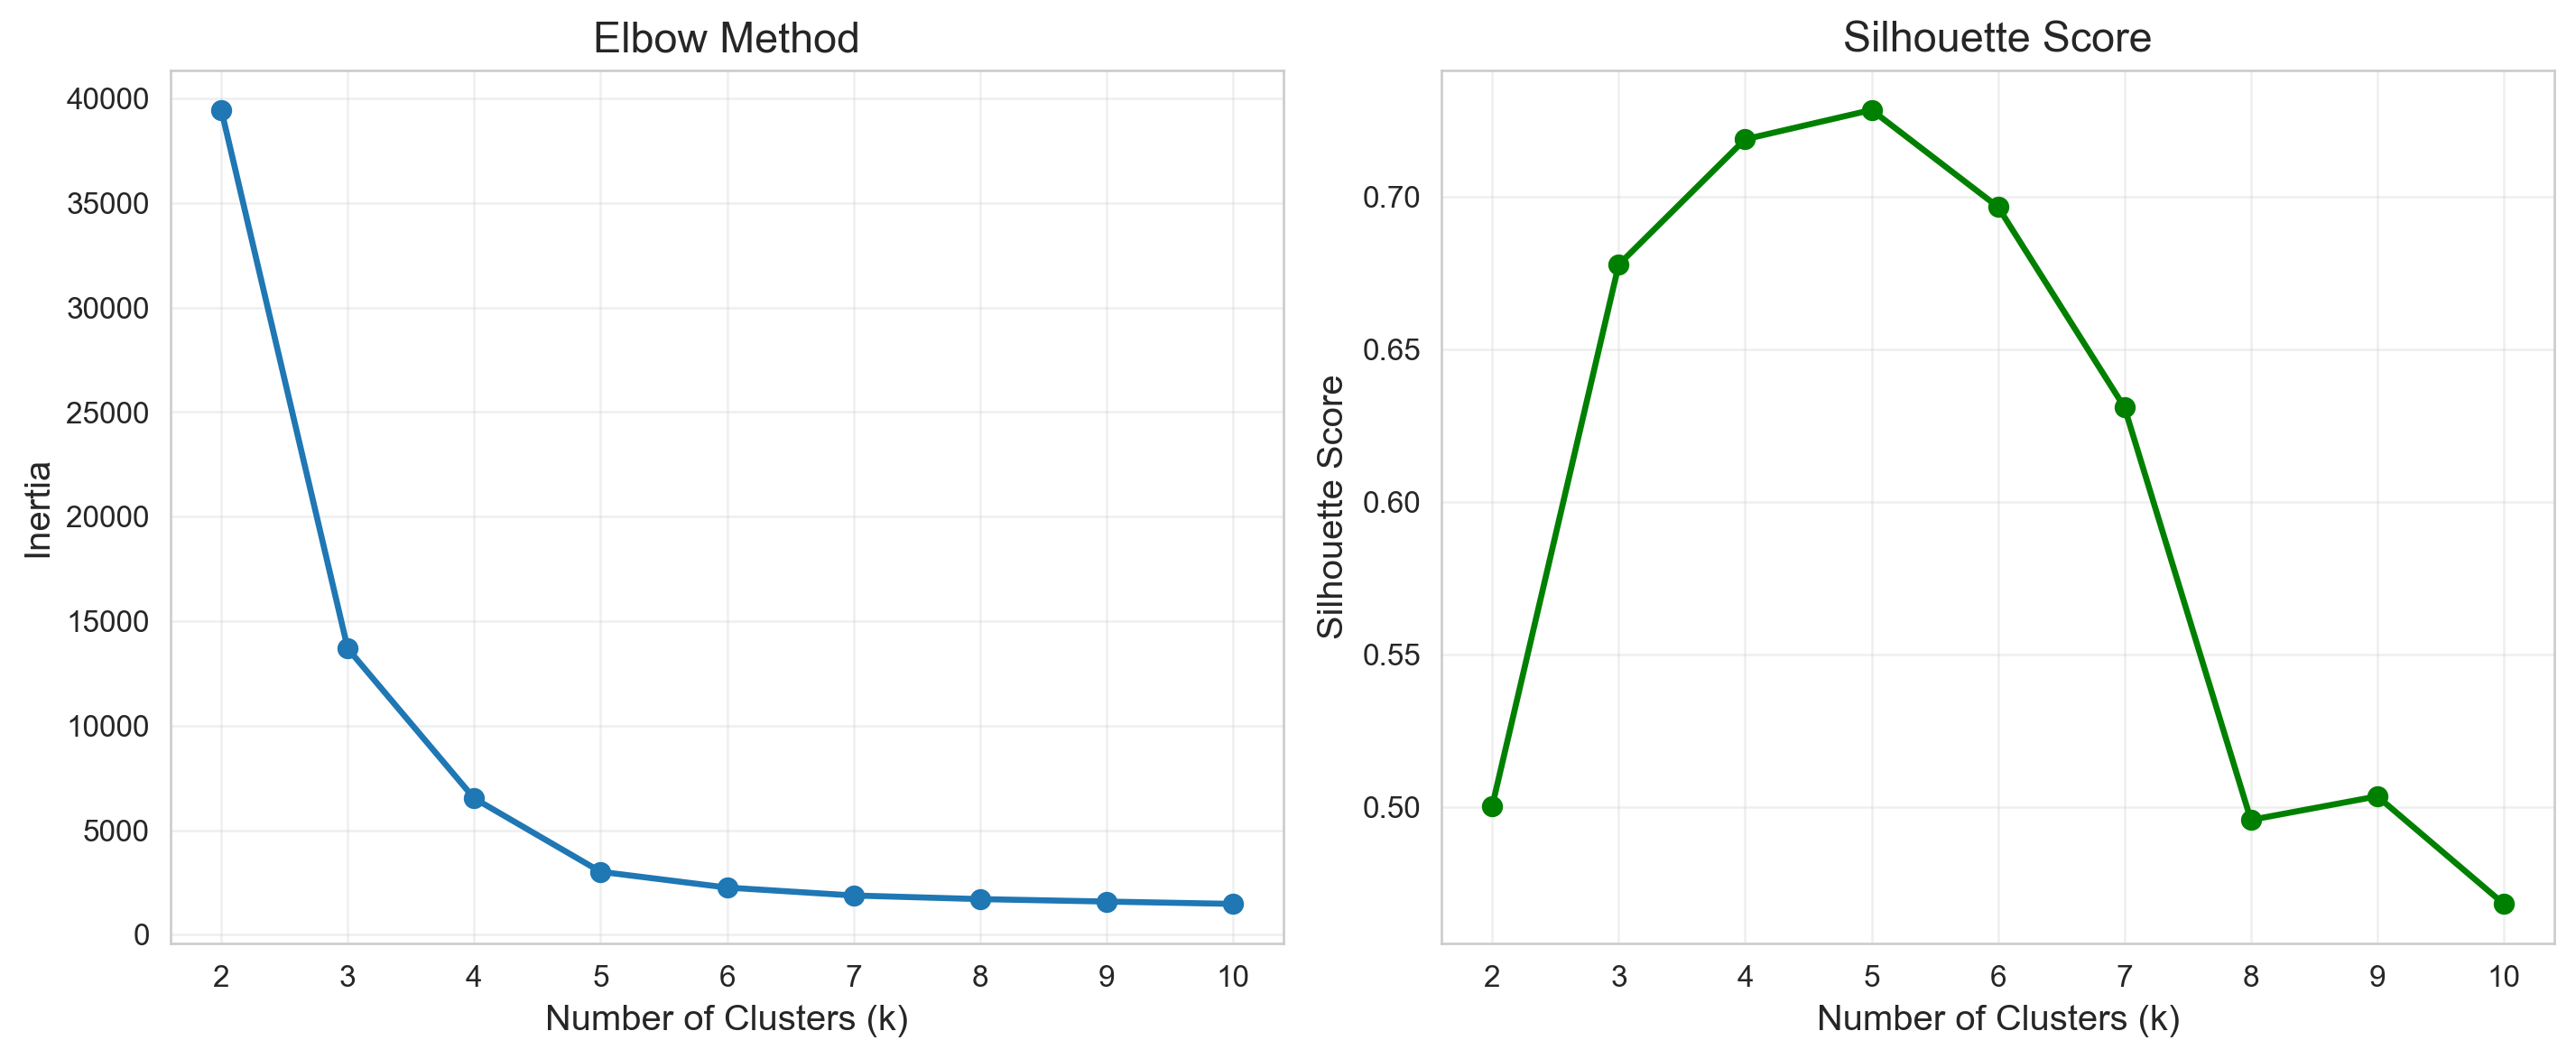

Optimal number of clusters (Silhouette): 5
Optimal number of clusters (Elbow - visual inspection): ~8 (true number of clusters)


In [6]:
# %% Optimal K – Elbow and Silhouette
# Use the same data as before (synthetic with 8 clusters)
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(sil_score)

# Plot Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', linewidth=2)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/optimal_k_elbow_silhouette.png', dpi=300)
plt.show()

# Best K from silhouette
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (Silhouette): {best_k}")
print(f"Optimal number of clusters (Elbow - visual inspection): ~{8} (true number of clusters)")

## 5. K‑Medoids (K‑Medians)

K‑Medoids is a robust alternative to K‑Means that uses actual data points as centroids (medoids). It is less sensitive to outliers and works well with non‑Euclidean distances.

We apply K‑Medoids to the same synthetic data.

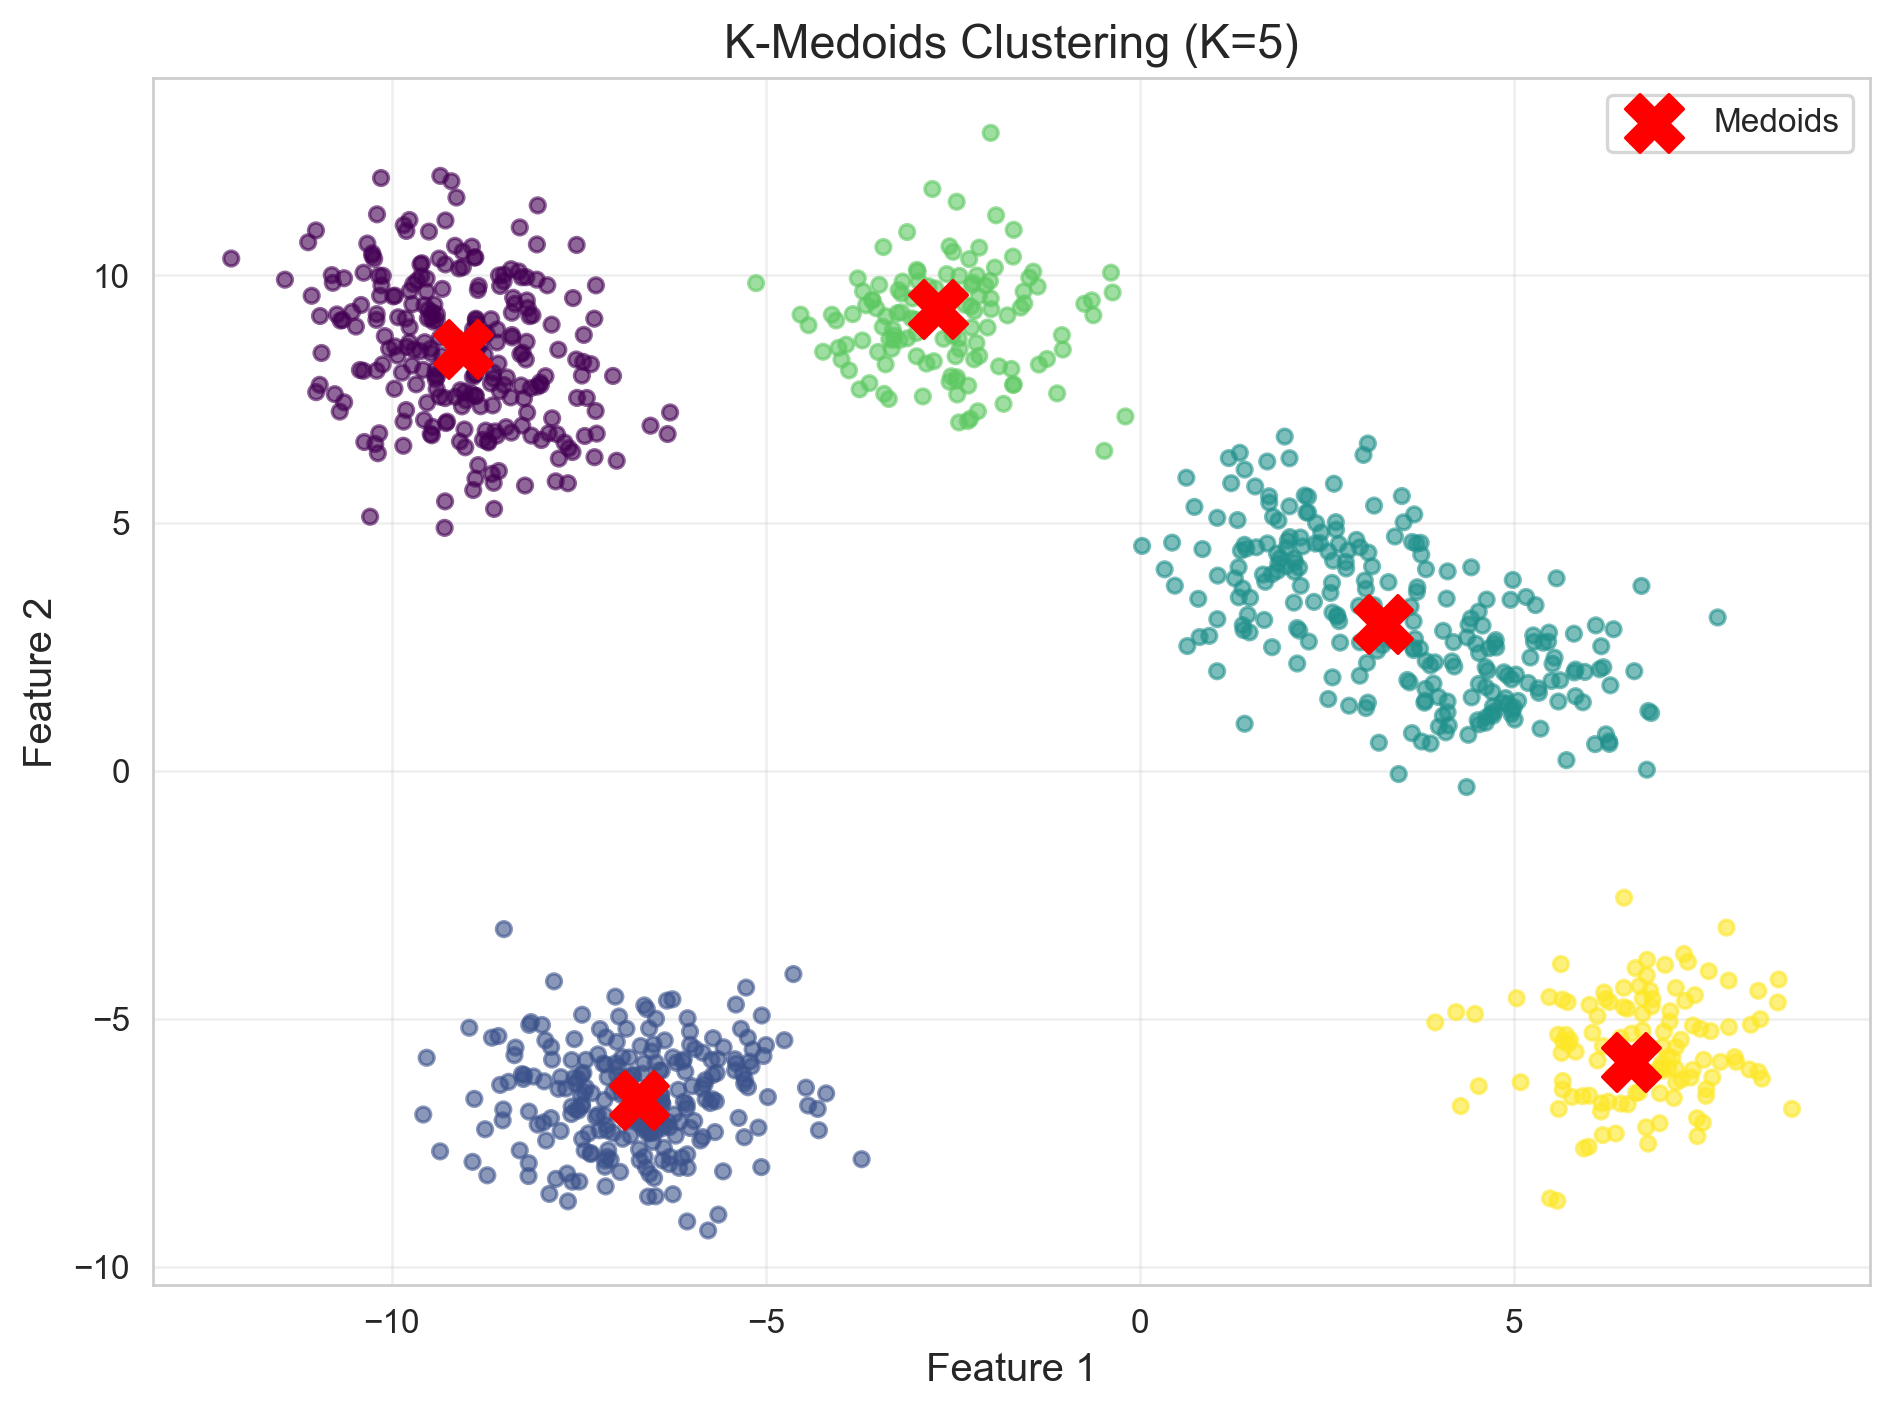

In [7]:
# %% K-Medoids
# Use the data from make_blobs (X)
kmedoids = KMedoids(n_clusters=best_k, method='pam', random_state=42)
labels_kmedoids = kmedoids.fit_predict(X)
centroids_kmedoids = kmedoids.cluster_centers_

# Visualise
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmedoids, cmap='viridis', alpha=0.6, s=20)
plt.scatter(centroids_kmedoids[:, 0], centroids_kmedoids[:, 1],
            s=300, c='red', marker='X', label='Medoids')
plt.title(f'K-Medoids Clustering (K={best_k})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/kmedoids_clustering.png', dpi=300)
plt.show()

## Summary and Next Steps

**Accomplished:**
- Implemented K‑Means from scratch using NumPy, including both random and K‑Means++ initialisation, demonstrating a deep understanding of the algorithm's mechanics.
- Visualised the convergence of K‑Means and K‑Means++ side‑by‑side, showing that **K‑Means++ leads to faster convergence and better cluster assignments**.
- Generated synthetic data using `make_blobs` with 8 true clusters and successfully identified the optimal number of clusters using two complementary methods:
  - **Elbow Method** – visual inspection suggested ~8 clusters, matching the true number.
  - **Silhouette Score** – identified 5 as the optimal K for this dataset, highlighting the importance of using multiple criteria for cluster validation.
- Applied **K‑Medoids (K‑Medians)** using `scikit-learn-extra` as a robust alternative to K‑Means, demonstrating its use with the `pam` algorithm.

**Key Results (Synthetic Data, 8 true clusters):**
| Method | Optimal K |
|--------|-----------|
| Elbow Method (visual) | ~8 |
| Silhouette Score | 5 |
| K‑Medoids (K=5) | Clustering visualised |

**Key Insights:**
- **K‑Means is a simple but powerful clustering algorithm**, but it is sensitive to initialisation. **K‑Means++** significantly improves initialisation quality, leading to more consistent and faster convergence.
- The **Elbow Method** is intuitive but subjective; the **Silhouette Score** provides a more objective, quantitative measure of cluster quality. In this dataset, the true number of clusters (8) was visually identifiable in the elbow plot, but the silhouette score suggested 5, indicating that the data may have hierarchical or overlapping cluster structures.
- **K‑Medoids** is a robust alternative to K‑Means, especially when outliers are present or when the data is not well‑suited to Euclidean distance. It uses actual data points as centroids, making it more interpretable in some contexts.
- The convergence visualisation clearly demonstrates how K‑Means++ avoids poor local minima and reaches a stable solution in fewer iterations compared to random initialisation.
- **The choice of K is not always clear‑cut**; it depends on the application, the data, and the desired level of granularity. Multiple criteria (elbow, silhouette, domain knowledge) should be used together.

**Suggested Next Steps:**
1. **Feature Scaling:** Always scale features before applying K‑Means, as it is sensitive to the scale of the data. This notebook used unscaled data for demonstration; in practice, use `StandardScaler` or `MinMaxScaler`.
2. **Dimensionality Reduction:** Apply PCA or t‑SNE before clustering to visualise high‑dimensional data or reduce noise.
3. **Cluster Profiling:** For real‑world datasets, profile each cluster by computing summary statistics of the original features to interpret the clusters meaningfully.
4. **Hierarchical Clustering:** Compare K‑Means results with hierarchical clustering and DBSCAN to understand the data's structure from multiple perspectives.
5. **Stability Analysis:** Run K‑Means multiple times with different random seeds to check the stability of the clusters.
6. **Outlier Detection:** Use clustering to identify outliers (points far from any centroid) for further investigation.
7. **Deployment:** Save the trained K‑Means model (using `joblib` or `pickle`) for real‑time clustering of new data.
8. **Real‑World Application:** Apply K‑Means to a real dataset (e.g., customer segmentation, image compression, anomaly detection) and evaluate the business impact.

**Reflection:**
K‑Means is a foundational unsupervised learning algorithm that is widely used in industry and research. This notebook demonstrates a complete workflow: from theoretical understanding and scratch implementation to evaluation and visualisation. The comparison between random and K‑Means++ initialisation highlights the importance of careful algorithm design, while the use of multiple cluster validity indices (elbow, silhouette) reinforces the principle that there is no single "correct" K – the optimal choice depends on the data and the problem context. The K‑Medoids extension provides a valuable alternative for scenarios where outliers or non‑Euclidean distances are a concern. This notebook provides a solid foundation for applying and understanding centroid‑based clustering methods.